# Coursework Set week 4

**Common remarks**:

* Deadline: Sunday at 23:59h for the week of this task
* <font color='red'>Keep all the information in this template unaltered!</font>

**Please fill in the following fields:**

* Name: Eszter B. Bartucz
* Username: ebbartucz
* Student number: s6362311
* Group (AS1, etc.): AS4

-----

In [1]:
totalpoints = currentpoints = 0

### Monte Carlo Error Propagation (4 pt) <font color='red'><b>COURSEWORK</b></font>

One of the classical Physic Lab experiment is to use pendulum to calculate the local gravitational acceleration, ``g``, from the measurements of the pendulum length ``L`` and the oscillation period ``T``.

The formula is expressed as follows:

$$ g=\frac{4\pi^2 L}{T^2} $$

You have got a set of measurements of $L=1.00\pm0.01\ \mathrm{(m)}$ and $T=2.01\pm0.02\ \mathrm{(s)}$.

* Like in Physics Lab, use Tyler expansion described above to propagate the error. Write your derivation in Markdown.

* Calculate the error of the derived ``g``.

* Apply Monte Carlo error propagation to estimate the value and uncertainty of ``g``.

* Make appropriate comments.

* Compare the two results.

The error of the derived $g$:


$\Delta g = \sqrt{(\frac{\partial g}{\partial L}\cdot \Delta L)^2+(\frac{\partial g}{\partial T}\cdot \Delta T)^2} $


$\Delta g = \sqrt{(\frac{4\pi^2}{T^2}\cdot \Delta L)^2+(-\frac{8\pi^2L}{T^3}\cdot \Delta T)^2}$

In [2]:
from math import *
import numpy as np

L = 1.00
dL = 0.01
T = 2.01
dT = 0.02

g = (4*pi**2*L)/T**2 # the value of g from the given values

dg = sqrt(((4*pi**2*dL)/(T**2))**2+((-8*pi**2*L*dT)/(T**3))**2) # error of g from taylor expansion

print(f"The error of g using Taylor expansion: {dg:.2f} m/s^2.")

Ldata = np.linspace(L-dL,L+dL,20) # creating uniform distribution for measurements of each quantity
Tdata = np.linspace(T-dT,T+dT,20) 

g_sample = [] # this will be the Monte Carlo sample of g

for i in range (10):
    a = Ldata[np.random.randint(len(Ldata))] # choosing a random index in the created data and adding the corresponding calculated g value to the sample
    b = Tdata[np.random.randint(len(Tdata))]
    g_sample.append((4*pi**2*a)/b**2)

g_mean = np.mean(g_sample) # using numpy to calculate the mean and standard deviation of the sample
g_sigma = np.std(g_sample)

print(f"The mean of the sample of g is: {g_mean:.2f} m/s^2, and the standard deviation is: {g_sigma:.2f} m/s^2.") 

#comparing the two results:

print(f"The difference between the two values: {abs(g_mean-g):.2f} m/s^2, and the difference between the errors: {abs(g_sigma-dg):.2f} m/s^2")

The error of g using Taylor expansion: 0.22 m/s^2.
The mean of the sample of g is: 9.77 m/s^2, and the standard deviation is: 0.12 m/s^2.
The difference between the two values: 0.00 m/s^2, and the difference between the errors: 0.10 m/s^2


In [3]:
# Leave unaltered
totalpoints += 4
currentpoints += 0.0

### Complex roots of a quadratic equation (4 pt) <font color='red'><b>COURSEWORK</b></font>
  
Use the information in the notebook about complex numbers to write a program that can calculate the (complex) roots of a quadratic equation with the quadratic formula:

$$ y=ax^2+bx+c $$

The requirement of this program is as follows:

* User can supply constants ``a``, ``b`` and ``c`` with Python function `input()`.
* The program can deal with complex roots.
* Your program must print the equation with its constants and its roots.
* The solutions must be inserted to the original equation to prove that $f(x)=0$.

**Answer**:

In [4]:
from math import sqrt

a=int(input("Enter coefficient a:")) # allowing the user to enter the coefficients
b=int(input("Enter coefficient b:"))
c=int(input("Enter coefficient c:"))

D=b**2-4*a*c # calculating the discriminant

if D > 0: # two real solutions
    x1 = (-b+sqrt(D))/(2*a) # calculated via the quadratic formula
    x2 = (-b-sqrt(D))/(2*a)
    
    print(f"There are two real solutions to the quadratic equation, which are:{x1} and {x2}") 
    print(f"The equation solved is:{a}x^2+{b}x+{c}=0.") # the equation is printed with the inputed coefficients
    if a*x1**2+b*x1+c ==0 and a*x2**2+b*x2+c==0: # checking if the solutions satisfy the homogeneous equation
        print("The solutions satisfy the equation.")
    
elif D==0:
    x=-b/(2*a) # calculated via the quadratic formula

    print(f"There is one real solution to the quadratic equation, namely: {x}")
    print(f"The equation solved is:{a}x^2+{b}x+{c}=0.")# the equation is printed with the inputed coefficients
    if a*x**2+b*x+c ==0: # checking if the solutions satisfy the homogeneous equation
        print("The solution satisfies the equation.")
          
else: #this is the part that considers complex numbers as solutions
    x1 = -b/(2*a)+(sqrt(-D)/(2*a))*1j # since D<0,sqrt(-D) is the coefficient of the imaginary part of the complex solution
    x2 = -b/(2*a)-(sqrt(-D)/(2*a))*1j
    
    print(f"There are two complex solutions to the quadratic equation, which are:{x1} and {x2}")
    print(f"The equation solved is:{a}x^2+{b}x+{c}=0.") # the equation is printed with the inputed coefficients
    if (x1**2+b*x1+c).real <= 10e-5 and (a*x2**2+b*x2+c).real <= 10e-5: # due to the limited memory of Python, the left side will equal a very small value rather than zero
        print("The solutions satisfy the equation.") # checking if the solutions satisfy the homogeneous equation

Enter coefficient a: 1
Enter coefficient b: 2
Enter coefficient c: 3


There are two complex solutions to the quadratic equation, which are:(-1+1.4142135623730951j) and (-1-1.4142135623730951j)
The equation solved is:1x^2+2x+3=0.
The solutions satisfy the equation.


In [5]:
# Leave unaltered
totalpoints += 4
currentpoints += 0.0

### Area under a Gaussian (6 pt) <font color='red'><b>COURSEWORK</b></font>

A one dimensional Gaussian function is given by:

$$f(x) = A\ e^{\frac{-{(x-x_0)}^2}{2 \sigma^2}} + z_0$$

$A$ is the amplitude, $x_0$ is the position of the peak, $\sigma$ is the width of the peak
and $z_0$ is the offset in $y$.  

This function can be written in Python as follows:

```python
def gauss(x, A, x0, sigma, z0):
    return A*np.exp(-(x-x0)**2/(2*sigma**2))+z0
```

1. Set in the calling environment:
```python
    A = 1.0
    x0 = 0.0
    sig = 2.0
    z0 = 0.0
```
2. Plot this function between -10 and 10 with 200 samples.
3. Use function `scipy.integrate.quad()` to find the area between ``x=0`` and ``x=2.5``.
4. Use function `matplotlib.pyplot.fill_between()` to mark that area in your plot.
5. Calculate the area between $-\infty$ and $\infty$ ($\approx 5.01$).
6. Given is the integral for the total area under the curve:

    $$\int _{-\infty }^{\infty }Ae^{-(x-x_0)^{2}/(2\sigma^{2})}\,\mathrm{d}x=A \sigma \cdot {\sqrt {2\pi }}$$

   Calculate this area for the values of the parameters given above and prove with ``quad()`` that the two are the same.

7. Make the last part an executable script, called ``gaussarea``. The user can enter values for ``A``, ``x0``, ``sig`` and ``z0`` and the integration limits. The programme then calculates the area under the curve between the integration limits using function ``quad()``. The programme must includes a plot of the curve, the integration area, and the value of that area in a legend.
8. Insert the generated plot in a separate markdown cell below your code cell, and upload your script to GitHub. Provide your GitHub website link in the notebook too for TA to check. 
   
**Answers**:   

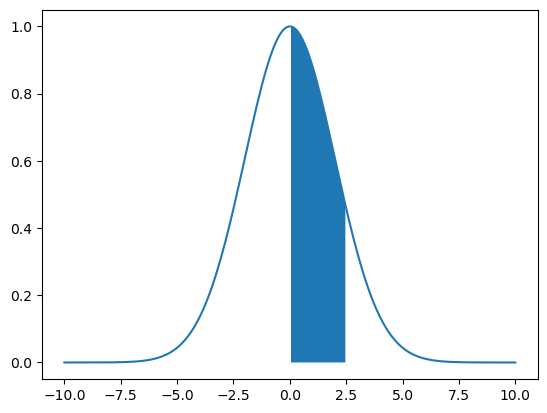

The are under the function integrated from 0 to 2.5: 1.9769788548675902
The area under the function integrated from negative to positive infinity: 5.013256549262001
The two methods give the same results!


In [6]:
import numpy as np
import scipy
from scipy import integrate
import matplotlib.pyplot as plt
from math import *

def gauss(x, A, x0, sigma, z0):
    return A*np.exp(-(x-x0)**2/(2*sigma**2))+z0 # the given function

A = 1.0 # setting the constants in the calling environment
x0 = 0.0
sig = 2.0
z0 = 0.0

x = np.linspace(-10,10,200) # creating range (from -10 to 10 with 200 samples)
y = gauss(x,A,x0,sig,z0) # values of the function on the range

X = x[np.where((0<=x) & (x<=2.5))] # keeping only 0<=x<=2.5 in the domain

plt.plot(x,y) # plotting the function over whole domain
plt.fill_between(X,gauss(X,A,x0,sig,z0),0) # filling only on desired range specified above to mark the calculated area
plt.show()

# calculating the areas under the curve with scipy.integrate.quad()

area1,error1 = scipy.integrate.quad(gauss,0,2.5, args = (A,x0,sig,z0,)) 
print(f"The are under the function integrated from 0 to 2.5: {area1}")

area2,error2 = scipy.integrate.quad(gauss,-np.inf,np.inf, args = (A,x0,sig,z0,))
print(f"The area under the function integrated from negative to positive infinity: {area2}")

areacheck = A*sig*sqrt(2*pi) # as per the given formula
if abs(areacheck - area2) <= 10**(-15): # again not zero due to the limited memory of Python
    print("The two methods give the same results!")
else:
    print(":(")


# the code exported as gaussarea.py:
'''
import numpy as np
import scipy
from scipy import integrate
import matplotlib.pyplot as plt
from math import *

A = float(input("Please enter value of parameter A:")) # allowing the user to input the parameters
x0 = float(input("Please enter value of parameter x0:"))
sig = float(input("Please enter value of parameter sig:"))
z0 = float(input("Please enter value of parameter z0:"))
a = float(input("Please enter value of the lower bound:"))
b = float(input("Please enter value of the upper bound:"))

def gauss(x, A, x0, sigma, z0):
    return A*np.exp(-(x-x0)**2/(2*sigma**2))+z0

x = np.linspace(-10,10,200) # setting the range
y = gauss(x,A,x0,sig,z0)

X = x[np.where((a<=x) & (x<=b))] # keeping only a<=x<=b in the domain

area1,error1 = scipy.integrate.quad(gauss,a,b, args = (A,x0,sig,z0,))

plt.rc('text', usetex = True)
plt.plot(x,y, )
plt.fill_between(X,gauss(X,A,x0,sig,z0),0, label = f"The area under the function \n integrated from {a} to {b}: \n {area1:.3f}")
plt.legend(loc = 'upper left')
plt.show()
'''

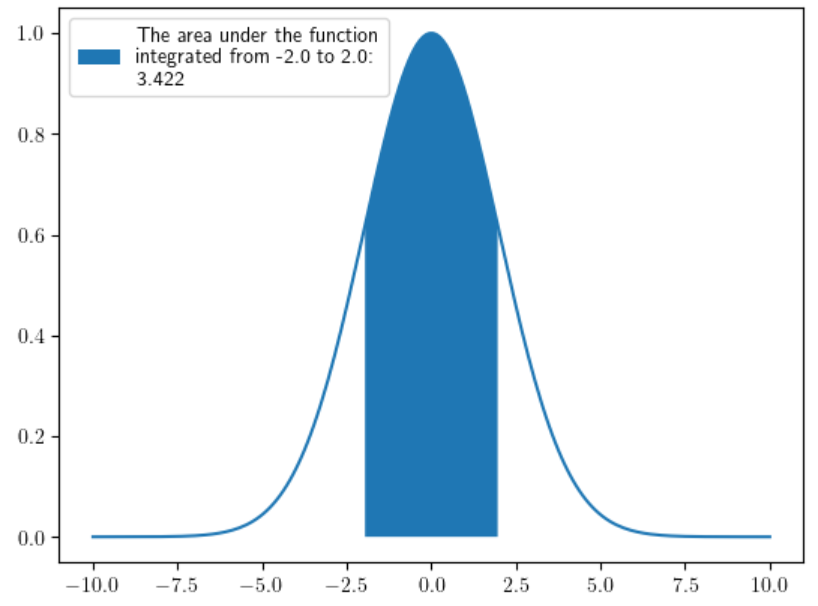

The above inserted graph can be found in my github repository with the name 'gaussarea photo.png' in case it is not visible.

LINK TO GITHUB: https://github.com/ebbartucz/PROGNUM-repo.git

In [7]:
# Leave unaltered
totalpoints += 6
currentpoints += 0.0

### Calculate integral of a user supplied function (6 pt) <font color='red'><b>COURSEWORK</b></font>

Write a programme that calculates the integral of any function from the user input using ``eval()``, which is a string representing a function and a variable (floating number) for which the function will be evaluated.

* Call from ``numpy import sin, cos, exp, pi`` to apply these functions and constants in your code.
* Use ``scipy.integrate.quad()`` to calculate the integral of the formula below between $x=0$ and $x=\pi$
* Use Monte Carlo Integration to calculate the integral of the formula below for $x=0$ and $x=\pi$

$$ f(x)=x^4+e^{\sin{x}+\cos{x}} $$

Make the function robust with try/except clauses. Demonstrate exceptions for wrong expressions and unknown functions in an expression (NameError) etc. Print messages that tell a user what they have done wrong!

Make the above code an executable script called ``interate_user_function``, and upload to GitHub.

* Create a separate cell, and use SymPy expression to calculate the integral of the formula below for $x=0$ and $x=\pi$.

In [8]:
import numpy as np
from numpy import sin, cos, exp, pi
import scipy
from scipy import integrate

while True: # endless loop inserted after requiring input to filter exceptions that arise when the input is invalid
    try:
        a = input("Please input the lower bound:")
        a = eval(a) # ensuring that a is a number or pi
        break
    except SyntaxError or ValueError:
        print(f"{a} is not a number or pi. Try again...")

while True: # endless loop inserted after requiring input to filter exceptions that arise when the input is invalid
    try:
        b = input("Please input the upper bound:")
        b = eval(b) # ensuring that b is a number or pi
        break
    except SyntaxError or ValueError:
        print(f"{b} is not a number or pi. Try again...")

n = 100000
x = np.random.uniform(a,b,n) # creating range

while True: # endless loop inserted after requiring input to filter exceptions that arise when the input is invalid
    try:
        y = input("Please input the function you wish to integrate:")
        s = eval(y)
        break
    except SyntaxError:
        print(f"{y} is not recognisable as a function. Try again...")

        
# EXAMPLE: input: '+' output: '+' is not recognisable as a function. Try again...
# a picture to illustrate this can be found in the next cell.
    

def I(x,y): # convert y from string to function
    '''
    The function converts a string to a function.
    Params: x (array) domain, over which y is evaluated.
            y (str) needs to be converted into a function.
    Return: I (func) the function created from y.
    '''
    I = eval(y)
    return I

integral1,error = scipy.integrate.quad(I,a,b,args = (y,))

print(f"The result of the user-supplied integral using the function 'scipy.integrate.quad()': {integral1}")

# using the above method to find the result of the given integral:

a = 0
b = pi
x = np.random.uniform(a,b,n) # creating range once again, for new, fixed a,b

def y(x):
    '''
    The function calculates the values of the given function for a domain.
    Params: x (array) the elements of the domain
    Return: y (array) the values of the function over the domain
    '''
    y = x**4+exp(sin(x)+cos(x))
    return y

integral2,error = scipy.integrate.quad(y,a,b)
print(f"The result of the integral of the given function': {integral2}")

def montecarlo(x,y):
    '''
    The function calculates the integral of a given function.
    Params: x (np.array) elements in the domain of the function
            y (array) the function that needs to be integrated
    Return: integral (float): the integral obtained via the Monte Carlo method
    '''
    integral = (np.max(x)-np.min(x))/len(x)*sum(y(x))
    return integral

print(f"The result of the integral using Monte Carlo's method: {montecarlo(x,y)}")


if abs(montecarlo(x,y)-integral2) <= 0.5: # not equal because monte carlo's is an approximation that is worse in the case of more steeply changing functions
    print("The two results are approximately the same.")


Please input the lower bound: 0
Please input the upper bound: 1
Please input the function you wish to integrate: x


The result of the user-supplied integral using the function 'scipy.integrate.quad()': 0.5
The result of the integral of the given function': 68.72932272689113
The result of the integral using Monte Carlo's method: 68.79419107942422
The two results are approximately the same.


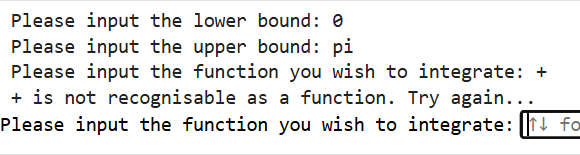

The above picture can also be found on my github in case it does not load here. The file name is 'not recognised.png'. https://github.com/ebbartucz/PROGNUM-repo.git

In [9]:
import sympy
from sympy.abc import x # ensuring that x is recognised as a sympy variable

s = "x**4 + exp(sin(x)+cos(x))"
intg = sympy.integrate(s, (x,0,pi)) # giving bounds
print(f"Integral of {s}: {intg.evalf()}") # evaluating

Integral of x**4 + exp(sin(x)+cos(x)): 68.7293227268911


In [10]:
# Leave unaltered
totalpoints += 6
currentpoints += 0.0

### Plotting Hertzsprung–Russell (HR) diagram (6 pt) <font color='red'><b>COURSEWORK</b></font>

``Hertzsprung-Russell (HR) diagram``, which indicates the stellar evolution, is an important astrophysical plot graphing stellar luminosity (brightness, absolute magnitude) against surface temperature (or colour). This diagram clearly states the evolutionary pathways of stars and where they are in their lifetime. With this, we classify several important stages of a star's life -- main sequence stars, giants, or white dwarfs. 

In this exercise, a combined APOGEE/Gaia star catalog has been prepared for you to create an HR diagram -- download the catalogue from the BrightSpace: ``APOGEE+Gaia_stars.fits``

* To read FITS file, you need AstroPy, which is a library that is widely used in Astronomy.

```python
from astropy.io import fits

# Open the FITS file
hdul = fits.open('APOGEE_stars.fits')

# Access the primary data (in this case, it is a Table)
data = hdul[1].data  # Often, the first extension contains the table
colnames = hdul[1].columns.names # List of the column names
```

* "data" is a AstroPy data class, but it can be used like a ndarray as follows.

```python
print(data[0]) # The first row of the catalogue
print(data['STARFLAG']) # List all rows in the column of "STARFLAG"
print(data['STARFLAG'][:10]) # Print the first 10 elements in the column of "STARFLAG"
print(data['STARFLAG'][-10:]) # Print the last 10 elements in the column of "STARFLAG"
```

* Firstly, let's select data with good quality and robust measurements using the following criteria:
    * STARFLAG == 0
    * ASPCAPFLAG == 0
    * SNR > 10
    * GAIAEDR3_PARALLAX/ GAIAEDR3_PARALLAX_ERROR > 5
    * GAIAEDR3_PHOT_G_MEAN_MAG is not NaN value
    * GAIAEDR3_PHOT_BP_MEAN_MAG is not NaN value
    * GAIAEDR3_PHOT_RP_MEAN_MAG is not NaN value

* From the selected data, let's randomly choose about **80% of the data** for plotting the HR diagram. 

* The HR diagram contains
    * $x$-axis: colour -- BP-RP
    * $y$-axis: absolute magnitude -- $M_G$


**<span style="color:red">Warning</span>**: note that from observation, we only have apparent magnitude (i.e. observed magnitude). To convert into absolute magnitude requires **Distance Modulus**: 

$$ M_G = m_G + 5\log10{(\mathrm{parallax}/1000)} + 5 $$

* Apply a rough binary classification scheme to separate giant branch and main sequence (MS) stars.
    * Giant branch: $ M_G<3.5 $ and $(BP-RP)>0.8$
    * MS: assume the rest of the data is MS

* It seems that we do not have sufficient samples in the White Dwarf (WD) region. Use the following criteria to draw vertical and horizontal lines, as well as define a box indicating the location of WD on the HR diagram.
    * $(BP-RP)\leq0.8$ and $ M_G>10 $ (very faint)
 
* Make a scatter plot and customise it to be look like the plot shown here.

<img src="attachment:14037eb3-1593-4349-8d4a-ae0bd96b6e97.png" alt="HR Diagram" width="600">

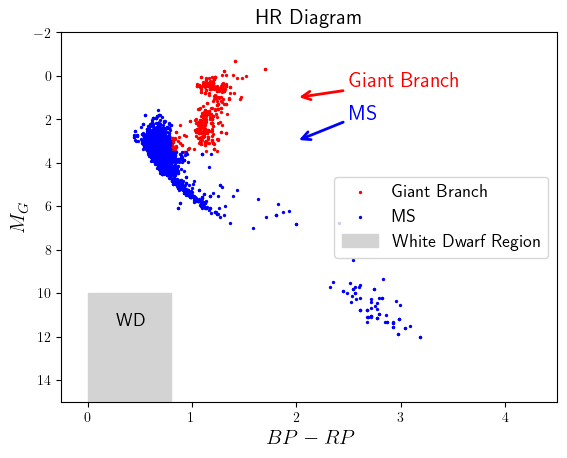

In [11]:
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt

# Open the FITS file
hdul = fits.open('APOGEE_stars.fits')

# Access the primary data (in this case, it is a Table)
data = hdul[1].data  # Often, the first extension contains the table
colnames = hdul[1].columns.names # List of the column names

mask_starflag = (data['STARFLAG']==0) # creating masks for all columns based on the conditions provided
mask_aspcapflag = (data['ASPCAPFLAG']==0)
mask_snr = (data['SNR']>10)
mask_parallax = (data['GAIAEDR3_PARALLAX']/data['GAIAEDR3_PARALLAX_ERROR'] > 250) # if instead of 250 we write 5 as asked, the plot looks nothing like the provided example
mask_magG = (~np.isnan(data['GAIAEDR3_PHOT_G_MEAN_MAG']))
mask_magBP = (~np.isnan(data['GAIAEDR3_PHOT_BP_MEAN_MAG']))
mask_magRP = (~np.isnan(data['GAIAEDR3_PHOT_RP_MEAN_MAG']))

mask = mask_starflag & mask_aspcapflag & mask_snr & mask_parallax & mask_magG & mask_magBP & mask_magRP # uniting all masks

datanew = data[mask] # using the mask on the data

# defining a list that contains the entries at randomly selected indeces for each of the quantities:
para_sel = [] 
G_sel = []
BP_sel = []
RP_sel = []
i=0 # initial condition for while loop

while i < 0.8*len(datanew['STARFLAG']): # ensuring 80% is selected
    q = np.random.randint(0,len(datanew['STARFLAG'])) # randomly selecting the indeces
    para_sel.append(datanew['GAIAEDR3_PARALLAX'][q]) # adding them to the corresponding list
    G_sel.append(datanew['GAIAEDR3_PHOT_G_MEAN_MAG'][q])
    BP_sel.append(datanew['GAIAEDR3_PHOT_BP_MEAN_MAG'][q])
    RP_sel.append(datanew['GAIAEDR3_PHOT_RP_MEAN_MAG'][q])
    i += 1
    
colour = np.array(BP_sel)-np.array(RP_sel) # defining colour (only numpy arrays can be added together, not lists)

M_G = np.array(G_sel) + 5*np.log10(np.array(para_sel)/1000) + 5  # distance modulus

colourGB = [] # empty lists for sorting
M_GGB = []
colourMS = []
M_GMS = []

for i in range (len(colour)):
    if M_G[i]<3.5 and colour[i]>0.8: #sorting criteria 
        colourGB.append(colour[i]) # appending lists with appropriate values 
        M_GGB.append(M_G[i])
    else:
        colourMS.append(colour[i])
        M_GMS.append(M_G[i])

plt.rc('text', usetex = True)
plt.title(f"HR Diagram", fontsize = 15)
plt.scatter(colourGB, M_GGB, color = 'red', s = 2.0, label = 'Giant Branch')
plt.scatter(colourMS, M_GMS, color = 'blue', s = 2.0, label = 'MS')
plt.xlim(-0.25,4.5)
plt.gca().invert_yaxis() # inverting the magnitude axis
plt.ylim(15,-2)
plt.xlabel(f"$BP-RP$", fontsize = 15)
plt.ylabel(f"$M_G$", fontsize = 15)

plt.annotate('Giant Branch', fontsize = 15, xy = (2,1),color = 'red', xytext = (2.5,0.5), arrowprops = {'linewidth':2,'arrowstyle':'->','color':'red'})
plt.annotate('MS', fontsize = 15, xy = (2,3),color = 'blue', xytext = (2.5,2), arrowprops = {'linewidth':2, 'arrowstyle':'->','color':'blue'})

plt.fill_between((0,0.8),16,10,color = 'lightgrey',label = "White Dwarf Region")
plt.annotate('WD',xy= (0.275,11.5), color = "black", fontsize = 13)
plt.legend(fontsize = 13, loc='center right')
plt.show()

The diagram in the case of "mask_parallax = (data['GAIAEDR3_PARALLAX']/data['GAIAEDR3_PARALLAX_ERROR'] > 250):

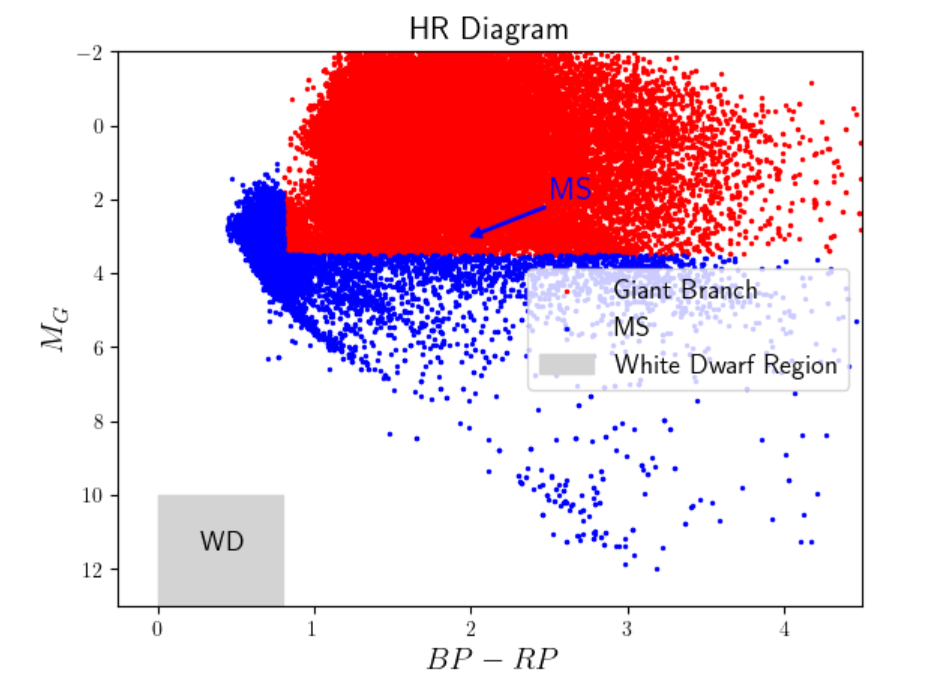

The above picture can also be found on my github in case it does not load here. The file name is 'error in 4.22.png'. https://github.com/ebbartucz/PROGNUM-repo.git

In [12]:
# Leave unaltered
totalpoints += 6
currentpoints += 0.0

## Finishing up

**Please read the section about your report in the task documentation very carefully before submitting it to BrightSpace.**

------------

## T.A. Grading


In [13]:
# Leave unaltered
taskgrade = round(10*currentpoints/totalpoints, 1) if totalpoints != 0 else 0
print(f"Total number of points: {totalpoints}. Student score: {currentpoints}.  Task Grade = {taskgrade}")

Total number of points: 26. Student score: 0.0.  Task Grade = 0.0
